<b>Employee Performance Analysis</b>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel(
    "INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xlsx"
)

df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [3]:
df.shape

(1200, 28)

In [4]:
df.shape

(1200, 28)

In [5]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [7]:
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [8]:
df.describe(include='object')

,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,2,6,3,6,19,3,2,2
top,E1001000,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,No,No
freq,1,725,492,548,373,270,846,847,1022


In [9]:
df.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

In [10]:
missing_percentage = df.isnull().mean() * 100

missing_percentage.sort_values(ascending=False)

EmpNumber                       0.0
Age                             0.0
Attrition                       0.0
YearsWithCurrManager            0.0
YearsSinceLastPromotion         0.0
ExperienceYearsInCurrentRole    0.0
ExperienceYearsAtThisCompany    0.0
EmpWorkLifeBalance              0.0
TrainingTimesLastYear           0.0
TotalWorkExperienceInYears      0.0
EmpRelationshipSatisfaction     0.0
EmpLastSalaryHikePercent        0.0
OverTime                        0.0
NumCompaniesWorked              0.0
EmpJobSatisfaction              0.0
EmpJobLevel                     0.0
EmpJobInvolvement               0.0
EmpHourlyRate                   0.0
EmpEnvironmentSatisfaction      0.0
EmpEducationLevel               0.0
DistanceFromHome                0.0
BusinessTravelFrequency         0.0
EmpJobRole                      0.0
EmpDepartment                   0.0
MaritalStatus                   0.0
EducationBackground             0.0
Gender                          0.0
PerformanceRating           

In [11]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 EmpNumber
['E1001000' 'E1001006' 'E1001007' ... 'E100994' 'E100995' 'E100998']

 Age
[32 47 40 41 60 27 50 28 36 38 44 30 29 42 34 39 56 53 35 52 33 25 45 23
 26 54 37 24 49 55 43 51 22 31 58 20 21 48 19 18 59 46 57]

 Gender
['Male' 'Female']

 EducationBackground
['Marketing' 'Life Sciences' 'Human Resources' 'Medical' 'Other'
 'Technical Degree']

 MaritalStatus
['Single' 'Married' 'Divorced']

 EmpDepartment
['Sales' 'Human Resources' 'Development' 'Data Science'
 'Research & Development' 'Finance']

 EmpJobRole
['Sales Executive' 'Manager' 'Developer' 'Sales Representative'
 'Human Resources' 'Senior Developer' 'Data Scientist'
 'Senior Manager R&D' 'Laboratory Technician' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Research Director'
 'Manager R&D' 'Finance Manager' 'Technical Architect' 'Business Analyst'
 'Technical Lead' 'Delivery Manager']

 BusinessTravelFrequency
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

 DistanceFromHome
[10 14  

PerformanceRating

In [18]:
df['PerformanceRating'].value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [19]:
df['PerformanceRating'].value_counts(normalize=True) * 100

PerformanceRating
3    72.833333
2    16.166667
4    11.000000
Name: proportion, dtype: float64

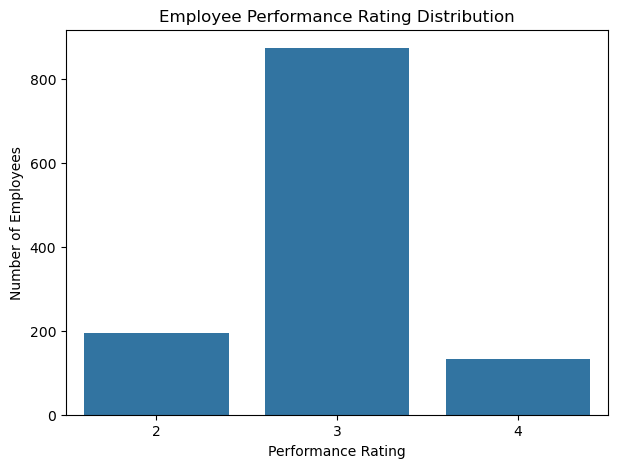

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='PerformanceRating'
)

plt.title('Employee Performance Rating Distribution')
plt.xlabel('Performance Rating')
plt.ylabel('Number of Employees')

plt.show()

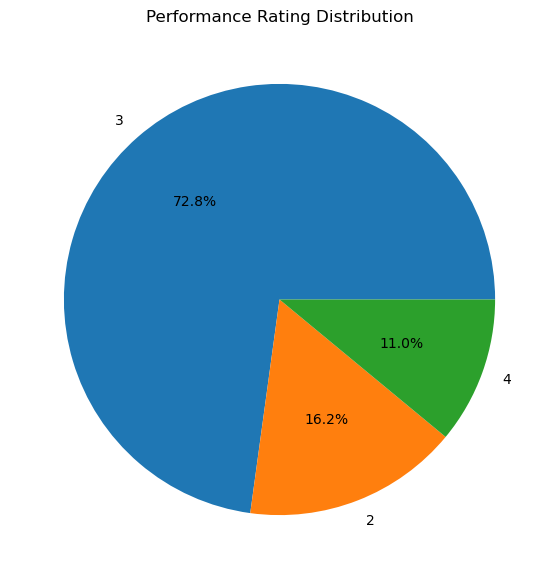

In [21]:
plt.figure(figsize=(7,7))

df['PerformanceRating'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Performance Rating Distribution')
plt.ylabel('')

plt.show()

In [22]:
df['EmpDepartment'].value_counts()

EmpDepartment
Sales                     373
Development               361
Research & Development    343
Human Resources            54
Finance                    49
Data Science               20
Name: count, dtype: int64

In [23]:
department_performance = pd.crosstab(
    df['EmpDepartment'],
    df['PerformanceRating']
)

department_performance

PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,1,17,2
Development,13,304,44
Finance,15,30,4
Human Resources,10,38,6
Research & Development,68,234,41
Sales,87,251,35


In [24]:
department_percentage = pd.crosstab(
    df['EmpDepartment'],
    df['PerformanceRating'],
    normalize='index'
) * 100

department_percentage

PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,5.000000,85.000000,10.000000
Development,3.601108,84.210526,12.188366
Finance,30.612245,61.224490,8.163265
Human Resources,18.518519,70.370370,11.111111
Research & Development,19.825073,68.221574,11.953353
Sales,23.324397,67.292225,9.383378


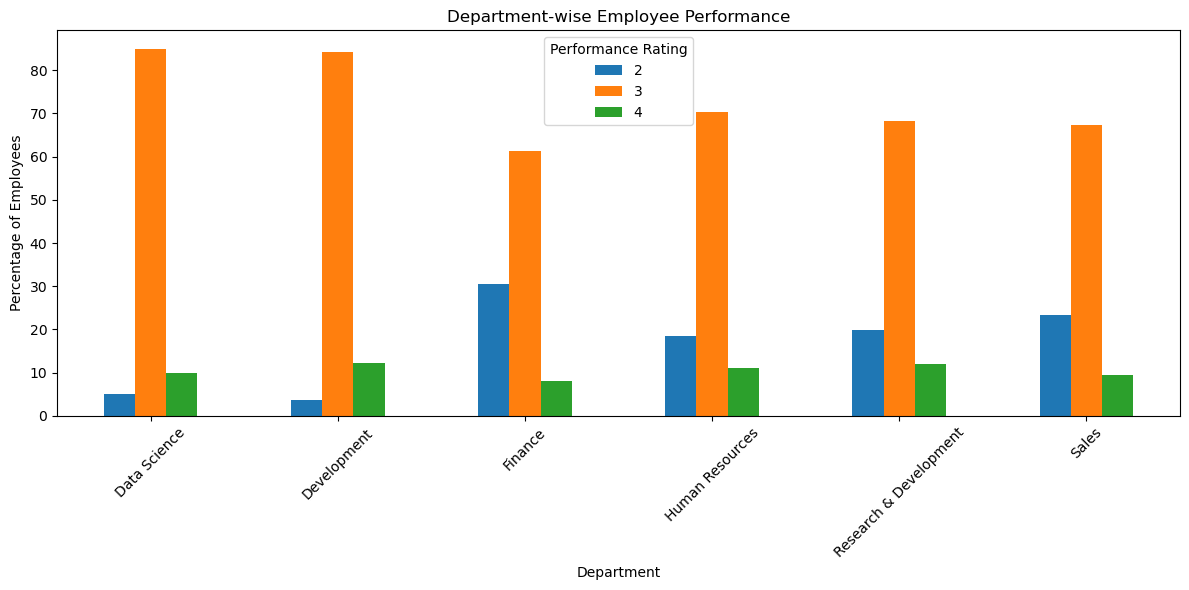

In [25]:
department_percentage.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Department-wise Employee Performance')
plt.xlabel('Department')
plt.ylabel('Percentage of Employees')
plt.xticks(rotation=45)

plt.legend(title='Performance Rating')

plt.tight_layout()
plt.show()

In [26]:
department_avg = df.groupby(
    'EmpDepartment'
)['PerformanceRating'].mean().sort_values(ascending=False)

department_avg

EmpDepartment
Development               3.085873
Data Science              3.050000
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Finance                   2.775510
Name: PerformanceRating, dtype: float64

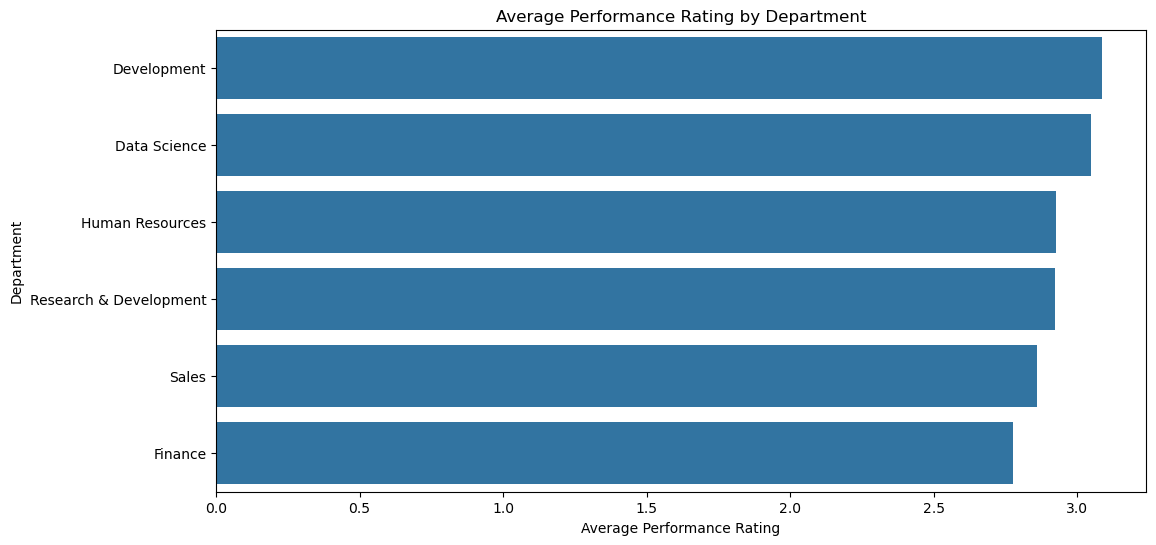

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=department_avg.values,
    y=department_avg.index
)

plt.title('Average Performance Rating by Department')
plt.xlabel('Average Performance Rating')
plt.ylabel('Department')

plt.show()

In [28]:
jobrole_performance = pd.crosstab(
    df['EmpJobRole'],
    df['PerformanceRating'],
    normalize='index'
) * 100

jobrole_performance

PerformanceRating,2,3,4
EmpJobRole,,,
Business Analyst,0.000000,81.250000,18.750000
Data Scientist,5.000000,85.000000,10.000000
Delivery Manager,0.000000,100.000000,0.000000
Developer,2.542373,84.322034,13.135593
Finance Manager,30.612245,61.224490,8.163265
Healthcare Representative,24.242424,66.666667,9.090909
Human Resources,20.000000,68.888889,11.111111
Laboratory Technician,21.875000,70.312500,7.812500
Manager,23.529412,56.862745,19.607843


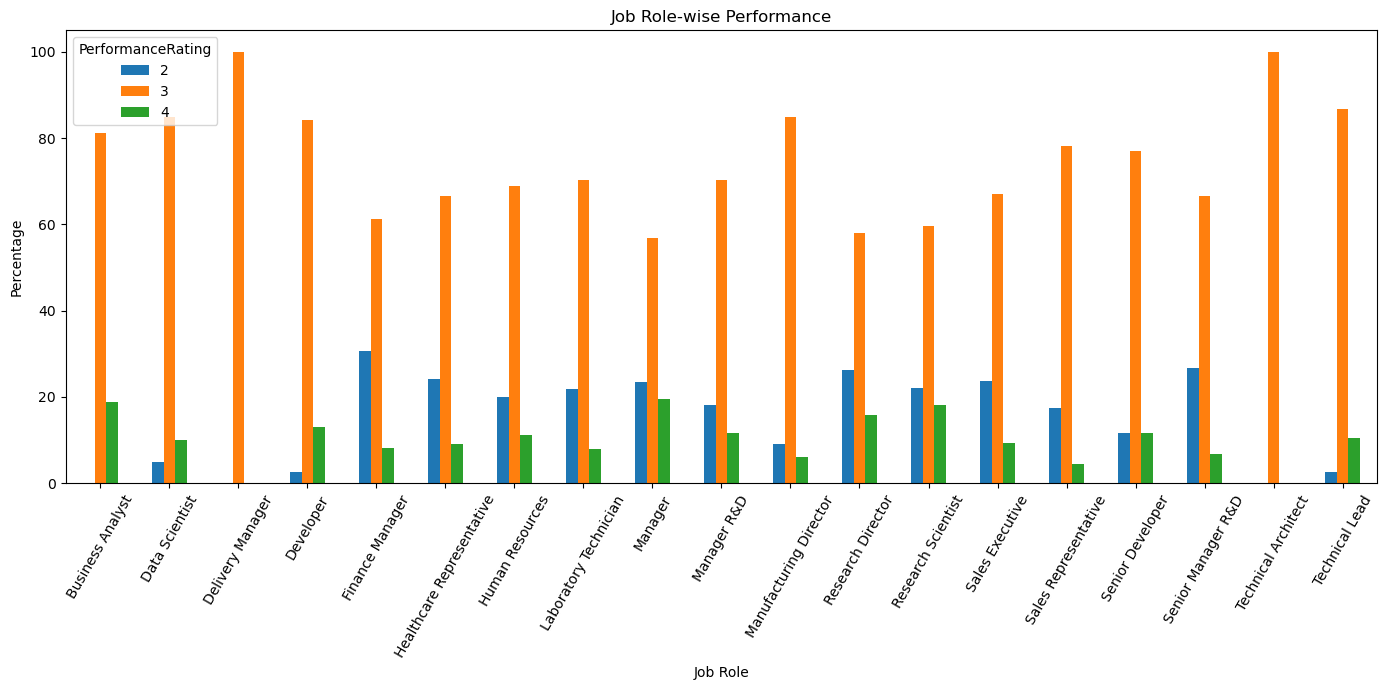

In [29]:
jobrole_performance.plot(
    kind='bar',
    figsize=(14,7)
)

plt.title('Job Role-wise Performance')
plt.xlabel('Job Role')
plt.ylabel('Percentage')

plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

In [30]:
gender_performance = pd.crosstab(
    df['Gender'],
    df['PerformanceRating'],
    normalize='index'
) * 100

gender_performance

PerformanceRating,2,3,4
Gender,,,
Female,15.789474,73.473684,10.736842
Male,16.413793,72.413793,11.172414


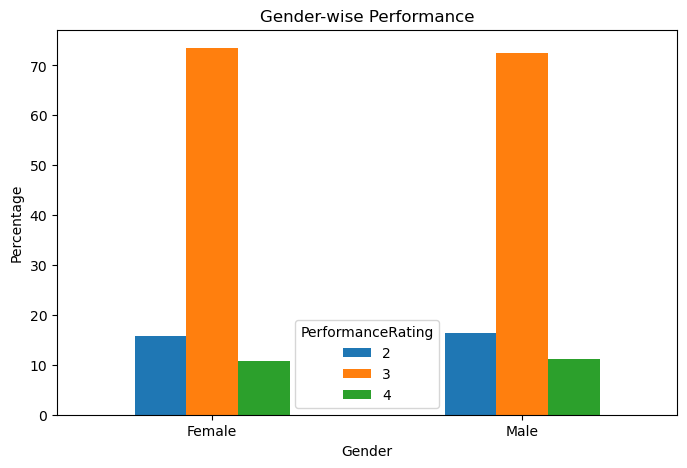

In [31]:
gender_performance.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Gender-wise Performance')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.show()

In [32]:
overtime_performance = pd.crosstab(
    df['OverTime'],
    df['PerformanceRating'],
    normalize='index'
) * 100

overtime_performance

PerformanceRating,2,3,4
OverTime,,,
No,18.299882,70.247934,11.452184
Yes,11.048159,79.036827,9.915014


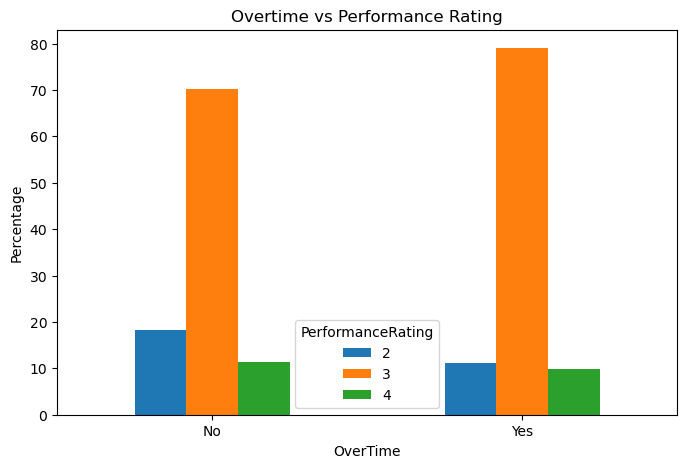

In [33]:
overtime_performance.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Overtime vs Performance Rating')
plt.xlabel('OverTime')
plt.ylabel('Percentage')

plt.xticks(rotation=0)

plt.show()

In [34]:
job_satisfaction = pd.crosstab(
    df['EmpJobSatisfaction'],
    df['PerformanceRating'],
    normalize='index'
) * 100

job_satisfaction

PerformanceRating,2,3,4
EmpJobSatisfaction,,,
1,16.450216,70.129870,13.419913
2,12.658228,79.324895,8.016878
3,19.209040,71.751412,9.039548
4,15.343915,71.428571,13.227513


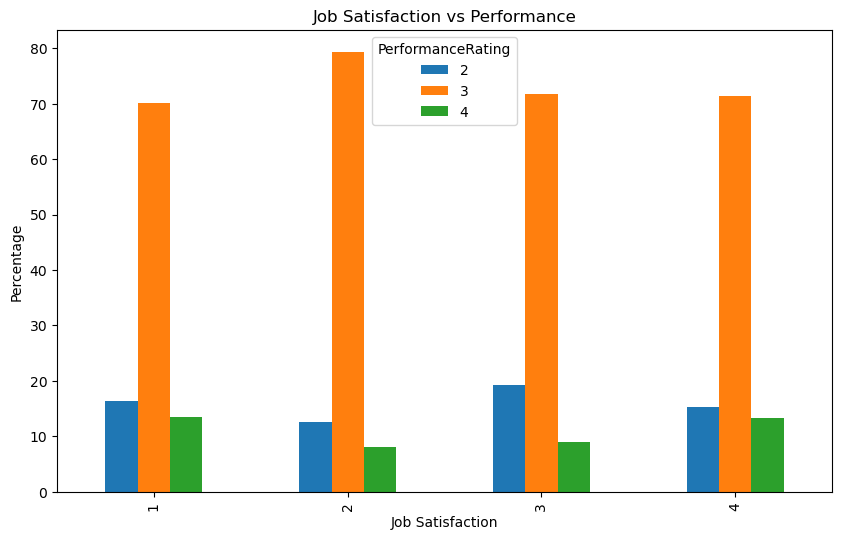

In [35]:
job_satisfaction.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Job Satisfaction vs Performance')
plt.xlabel('Job Satisfaction')
plt.ylabel('Percentage')

plt.show()

In [36]:
environment_satisfaction = pd.crosstab(
    df['EmpEnvironmentSatisfaction'],
    df['PerformanceRating'],
    normalize='index'
) * 100

environment_satisfaction

PerformanceRating,2,3,4
EmpEnvironmentSatisfaction,,,
1,39.130435,55.217391,5.652174
2,40.495868,53.719008,5.785124
3,0.817439,84.468665,14.713896
4,0.831025,85.041551,14.127424


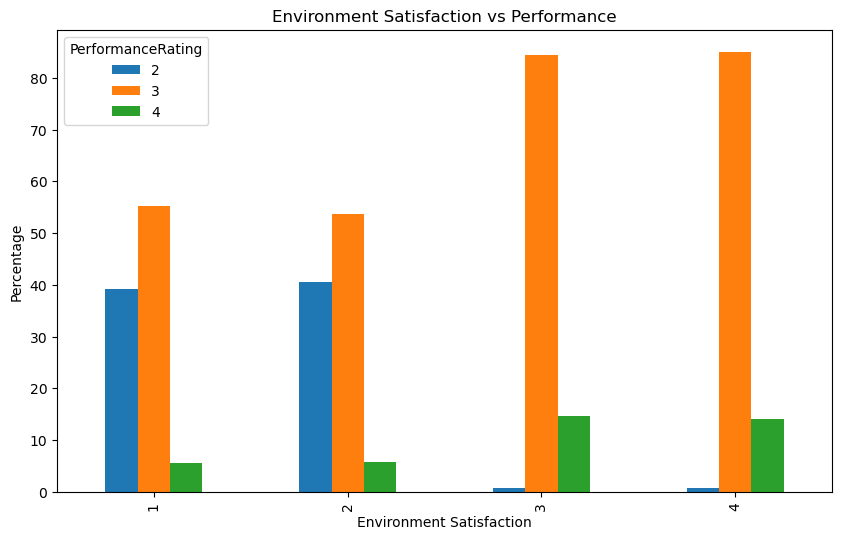

In [37]:
environment_satisfaction.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Environment Satisfaction vs Performance')
plt.xlabel('Environment Satisfaction')
plt.ylabel('Percentage')

plt.show()

In [38]:
worklife_performance = pd.crosstab(
    df['EmpWorkLifeBalance'],
    df['PerformanceRating'],
    normalize='index'
) * 100

worklife_performance

PerformanceRating,2,3,4
EmpWorkLifeBalance,,,
1,25.000000,75.000000,0.000000
2,17.346939,73.469388,9.183673
3,15.818432,73.314993,10.866575
4,10.434783,66.956522,22.608696


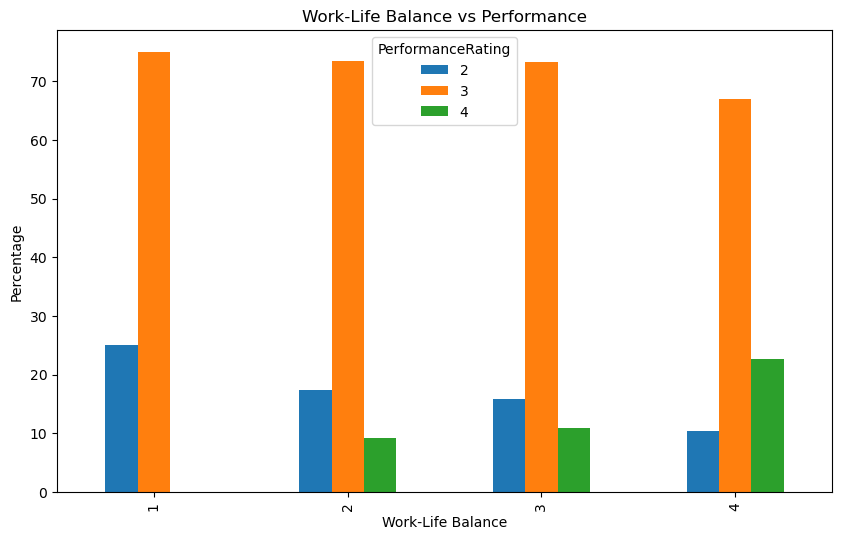

In [39]:
worklife_performance.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Work-Life Balance vs Performance')
plt.xlabel('Work-Life Balance')
plt.ylabel('Percentage')

plt.show()

In [40]:
training_performance = pd.crosstab(
    df['TrainingTimesLastYear'],
    df['PerformanceRating'],
    normalize='index'
) * 100

training_performance

PerformanceRating,2,3,4
TrainingTimesLastYear,,,
0,20.454545,72.727273,6.818182
1,19.642857,66.071429,14.285714
2,15.730337,73.707865,10.561798
3,15.496368,71.428571,13.075061
4,16.326531,75.510204,8.163265
5,16.326531,73.469388,10.204082
6,17.391304,78.260870,4.347826


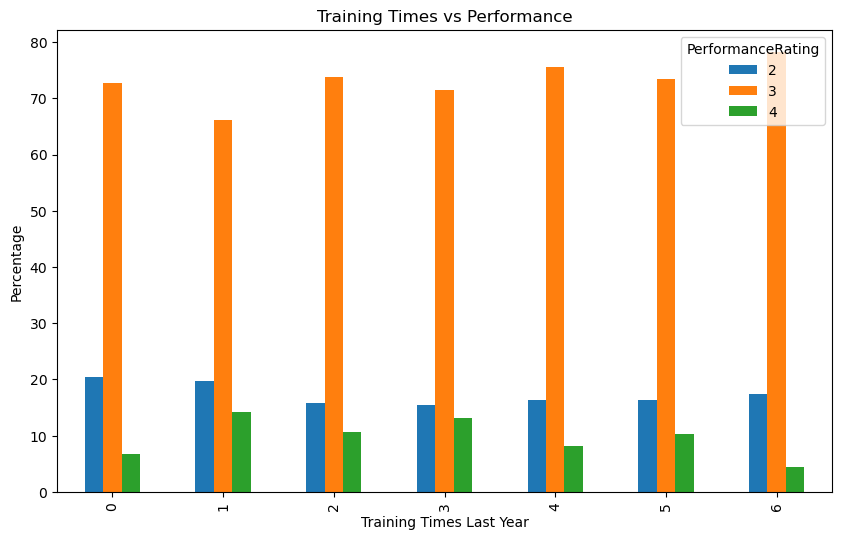

In [41]:
training_performance.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Training Times vs Performance')
plt.xlabel('Training Times Last Year')
plt.ylabel('Percentage')

plt.show()

In [42]:
numeric_df = df.select_dtypes(include=np.number)

In [43]:
correlation = numeric_df.corr()

correlation

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
Age,1.000000,0.020937,0.207313,0.013814,0.062867,0.027216,0.509139,-0.002436,0.284408,-0.006105,0.049749,0.680886,-0.016053,-0.019563,0.318852,0.217163,0.228199,0.205098,-0.040164
DistanceFromHome,0.020937,1.000000,0.045856,-0.017719,0.013730,0.003231,0.017270,-0.003036,-0.021411,0.044974,-0.009509,0.027306,-0.032082,-0.044788,0.021908,0.019898,0.013246,0.017860,-0.046142
EmpEducationLevel,0.207313,0.045856,1.000000,-0.037103,0.014095,0.027544,0.100734,0.000357,0.128674,0.002358,-0.016690,0.151062,-0.013674,0.010276,0.076332,0.066672,0.054313,0.088988,0.020529
EmpEnvironmentSatisfaction,0.013814,-0.017719,-0.037103,1.000000,-0.049501,0.004865,-0.008272,-0.004319,0.017270,-0.047271,-0.010504,-0.012894,0.001192,-0.000262,-0.000561,0.025491,0.010732,-0.011702,0.395561
EmpHourlyRate,0.062867,0.013730,0.014095,-0.049501,1.000000,0.054741,-0.018606,-0.066417,0.040484,-0.015934,0.008783,0.026034,-0.024160,0.016189,-0.000399,-0.011871,-0.010000,-0.004576,-0.043116
EmpJobInvolvement,0.027216,0.003231,0.027544,0.004865,0.054741,1.000000,-0.034349,-0.005501,0.018211,-0.001742,0.018037,-0.028851,-0.025168,-0.014129,-0.039720,0.002910,-0.019944,0.012924,-0.010539
EmpJobLevel,0.509139,0.017270,0.100734,-0.008272,-0.018606,-0.034349,1.000000,-0.011853,0.127477,-0.020975,0.002992,0.784229,-0.000389,0.049218,0.540377,0.399235,0.360880,0.374872,-0.076632
EmpJobSatisfaction,-0.002436,-0.003036,0.000357,-0.004319,-0.066417,-0.005501,-0.011853,1.000000,-0.049865,0.031847,-0.022028,-0.026824,-0.028031,-0.018548,0.001807,0.002018,-0.006508,-0.022096,0.000606
NumCompaniesWorked,0.284408,-0.021411,0.128674,0.017270,0.040484,0.018211,0.127477,-0.049865,1.000000,-0.011788,0.057917,0.221505,-0.050817,0.002489,-0.129797,-0.097271,-0.031656,-0.109937,0.020980
EmpLastSalaryHikePercent,-0.006105,0.044974,0.002358,-0.047271,-0.015934,-0.001742,-0.020975,0.031847,-0.011788,1.000000,-0.042892,-0.005933,-0.013439,-0.017001,-0.019830,-0.004957,-0.015911,-0.007666,0.333722


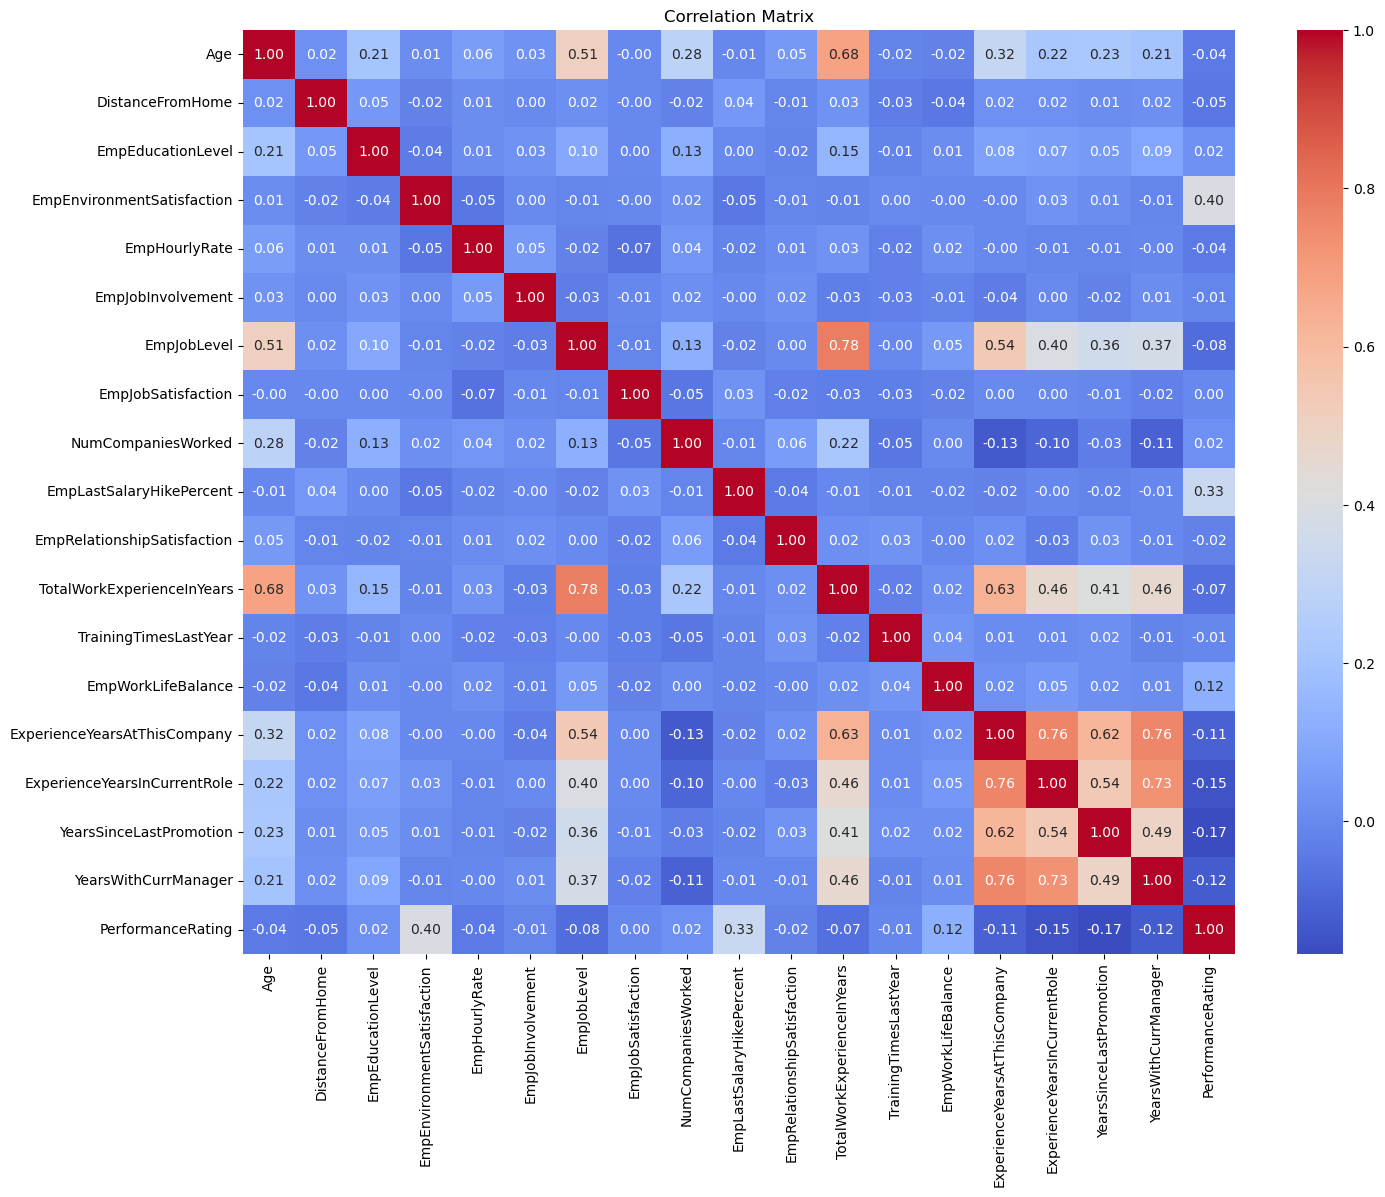

In [44]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [45]:
target_correlation = correlation[
    'PerformanceRating'
].sort_values(
    ascending=False
)

target_correlation

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EmpJobSatisfaction              0.000606
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsInCurrentRole   -0.147638
YearsSinceLastPromotion        -0.167629
Name: PerformanceRating, dtype: float64

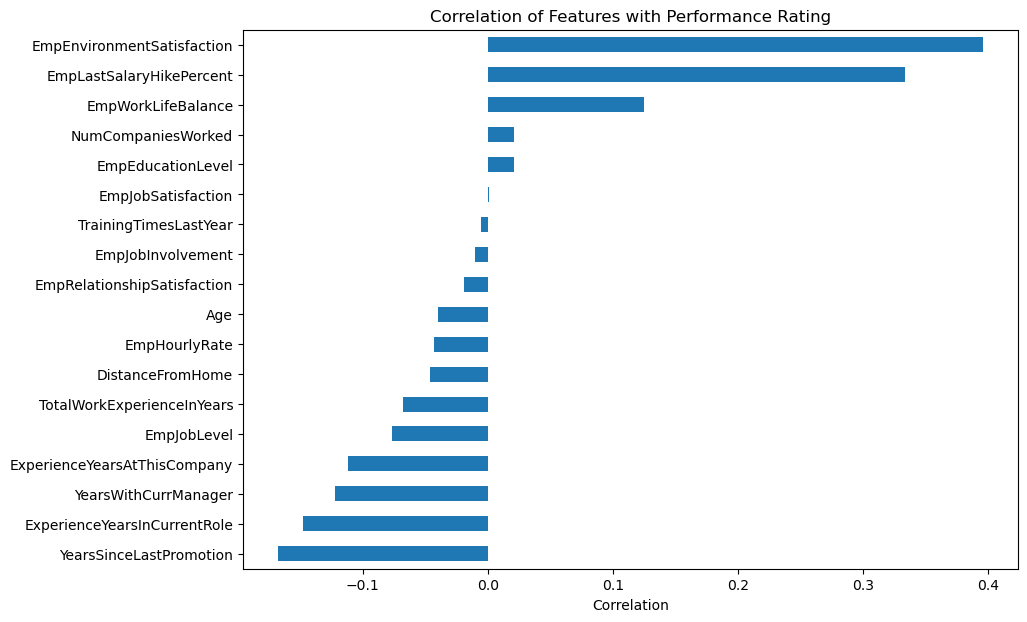

In [46]:
plt.figure(figsize=(10,7))

target_correlation.drop(
    'PerformanceRating'
).sort_values().plot(
    kind='barh'
)

plt.title('Correlation of Features with Performance Rating')
plt.xlabel('Correlation')

plt.show()

In [47]:
X = df.drop(
    columns=['PerformanceRating', 'EmpNumber']
)

y = df['PerformanceRating']

In [48]:
X.shape, y.shape

((1200, 26), (1200,))

In [49]:
categorical_columns = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition']

Numerical Columns:
['Age', 'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked', 'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction', 'TotalWorkExperienceInYears', 'TrainingTimesLastYear', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (960, 26)
Testing data: (240, 26)


In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_columns
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_columns
        )
    ]
)

In [54]:
lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [55]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(
          y_test,
          lr_pred,
          average='weighted'
      ))

print("Recall:",
      recall_score(
          y_test,
          lr_pred,
          average='weighted'
      ))

print("F1 Score:",
      f1_score(
          y_test,
          lr_pred,
          average='weighted'
      ))

Accuracy: 0.825
Precision: 0.816373089983022
Recall: 0.825
F1 Score: 0.8165070305138797


In [56]:
dt = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [57]:
rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [58]:
knn = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier(
            n_neighbors=5
        ))
    ]
)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [59]:
svm = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SVC(
            probability=True,
            random_state=42
        ))
    ]
)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [60]:
nb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GaussianNB())
    ]
)

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [62]:
et = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', ExtraTreesClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

et.fit(X_train, y_train)

et_pred = et.predict(X_test)

In [63]:
def evaluate_model(model_name, y_true, y_pred):
    
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(
            y_true,
            y_pred,
            average='weighted'
        ),
        'Recall': recall_score(
            y_true,
            y_pred,
            average='weighted'
        ),
        'F1 Score': f1_score(
            y_true,
            y_pred,
            average='weighted'
        )
    }

In [64]:
results = []

results.append(
    evaluate_model(
        'Logistic Regression',
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        'Decision Tree',
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        'KNN',
        y_test,
        knn_pred
    )
)

results.append(
    evaluate_model(
        'SVM',
        y_test,
        svm_pred
    )
)

results.append(
    evaluate_model(
        'Naive Bayes',
        y_test,
        nb_pred
    )
)

results.append(
    evaluate_model(
        'Extra Trees',
        y_test,
        et_pred
    )
)

model_results = pd.DataFrame(results)

model_results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.895833,0.893910,0.895833,0.893905
2,Random Forest,0.900000,0.905426,0.900000,0.893627
0,Logistic Regression,0.825000,0.816373,0.825000,0.816507
4,SVM,0.833333,0.845878,0.833333,0.811069
6,Extra Trees,0.812500,0.844704,0.812500,0.765812
3,KNN,0.762500,0.736939,0.762500,0.721492
5,Naive Bayes,0.204167,0.784388,0.204167,0.117565


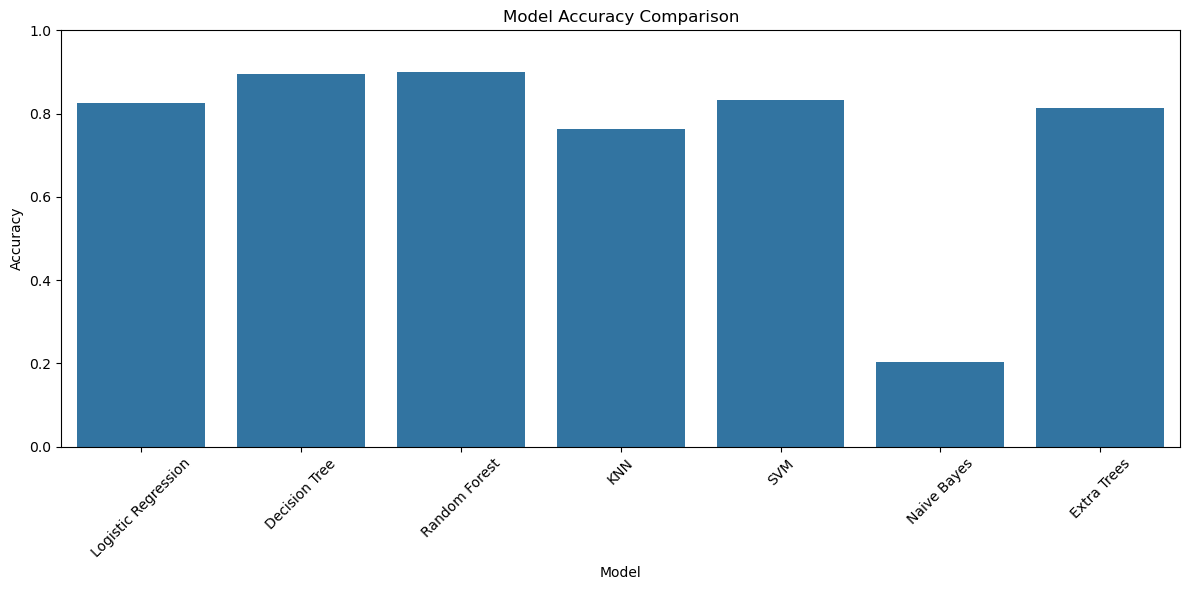

In [65]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=model_results,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.xticks(rotation=45)
plt.ylim(0,1)

plt.tight_layout()
plt.show()

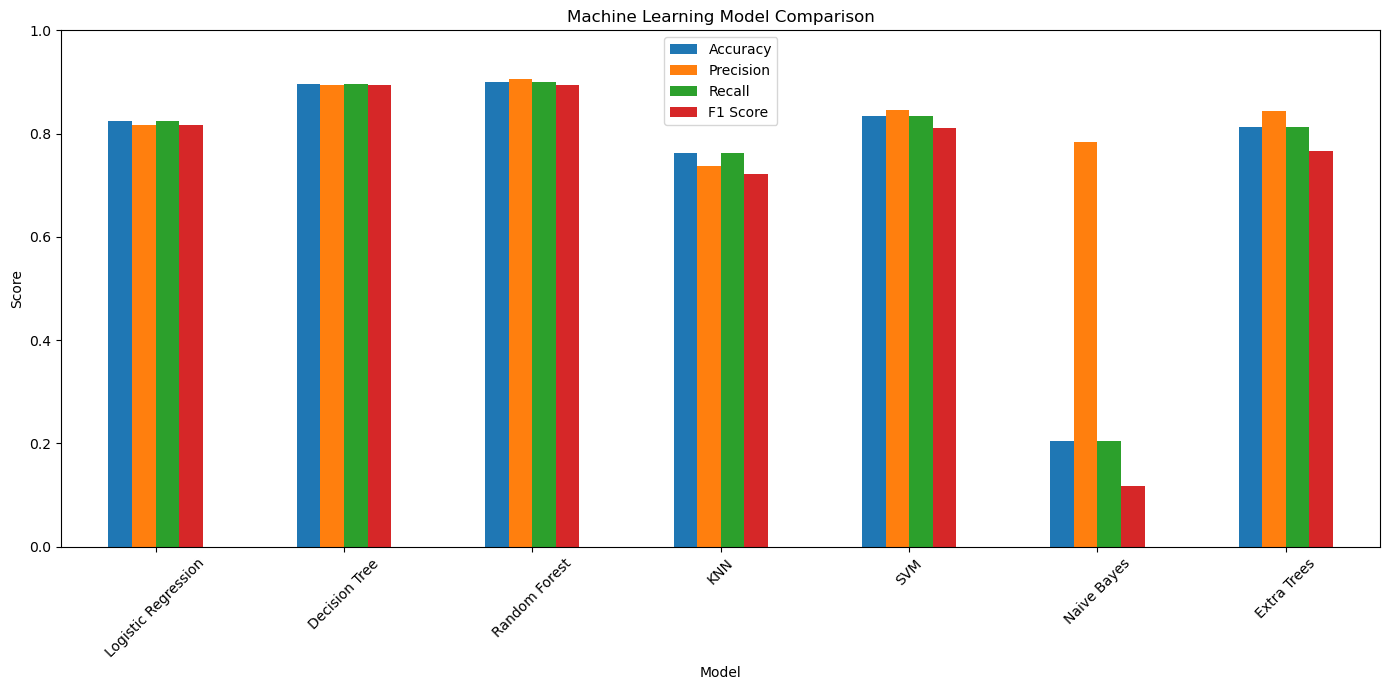

In [66]:
model_results.set_index(
    'Model'
)[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(14,7)
)

plt.title('Machine Learning Model Comparison')
plt.ylabel('Score')
plt.ylim(0,1)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [67]:
best_model_name = model_results.loc[
    model_results['F1 Score'].idxmax(),
    'Model'
]

best_model_name

'Decision Tree'

In [1]:
predictions = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'KNN': knn_pred,
    'SVM': svm_pred,
    'Naive Bayes': nb_pred,
    'Extra Trees': et_pred
}

NameError: name 'lr_pred' is not defined

In [71]:
best_pred = predictions[best_model_name]

In [72]:
cm = confusion_matrix(
    y_test,
    best_pred
)

cm

array([[ 29,  10,   0],
       [  6, 166,   3],
       [  0,   6,  20]])

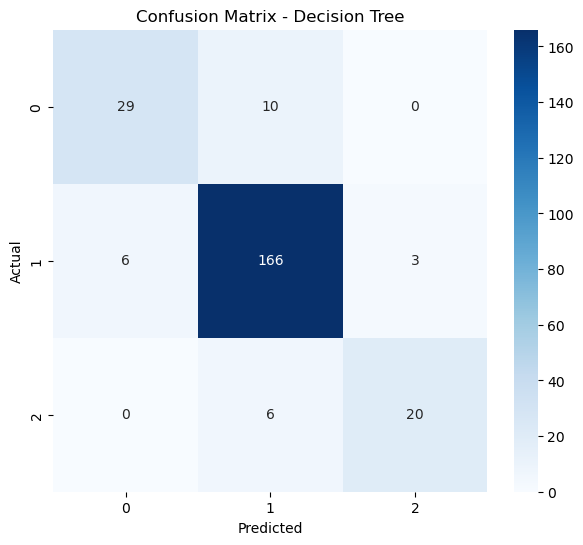

In [73]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix - {best_model_name}'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [74]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           2       0.83      0.74      0.78        39
           3       0.91      0.95      0.93       175
           4       0.87      0.77      0.82        26

    accuracy                           0.90       240
   macro avg       0.87      0.82      0.84       240
weighted avg       0.89      0.90      0.89       240



In [75]:
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN': knn,
    'SVM': svm,
    'Naive Bayes': nb,
    'Extra Trees': et
}

In [76]:
cv_results = []

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )
    
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by='CV Mean Accuracy',
    ascending=False
)

,Model,CV Mean Accuracy,CV Std
2,Random Forest,0.916667,0.031069
1,Decision Tree,0.879167,0.019543
0,Logistic Regression,0.812500,0.022361
4,SVM,0.799167,0.031225
6,Extra Trees,0.777500,0.035414
3,KNN,0.750833,0.010992
5,Naive Bayes,0.220833,0.036610


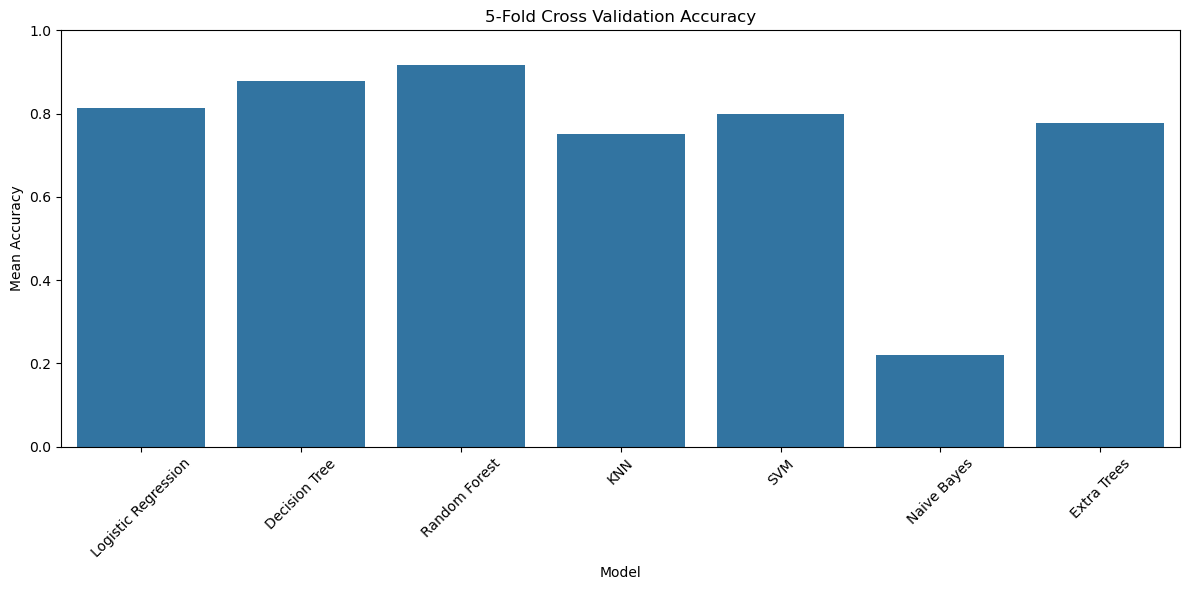

In [77]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=cv_results_df,
    x='Model',
    y='CV Mean Accuracy'
)

plt.title('5-Fold Cross Validation Accuracy')
plt.ylabel('Mean Accuracy')

plt.xticks(rotation=45)

plt.ylim(0,1)

plt.tight_layout()
plt.show()

In [78]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            random_state=42
        ))
    ]
)

In [79]:
rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [80]:
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [83]:
print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [82]:
print("Best CV Score:")
print(rf_grid.best_score_)

Best CV Score:
0.8949005396845596


In [84]:
tuned_rf_pred = rf_grid.predict(X_test)

In [85]:
print(
    classification_report(
        y_test,
        tuned_rf_pred
    )
)

              precision    recall  f1-score   support

           2       0.91      0.74      0.82        39
           3       0.89      0.98      0.93       175
           4       1.00      0.54      0.70        26

    accuracy                           0.90       240
   macro avg       0.93      0.75      0.82       240
weighted avg       0.90      0.90      0.89       240



In [86]:
print(
    "Accuracy:",
    accuracy_score(y_test, tuned_rf_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        tuned_rf_pred,
        average='weighted'
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        tuned_rf_pred,
        average='weighted'
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        tuned_rf_pred,
        average='weighted'
    )
)

Accuracy: 0.8958333333333334
Precision: 0.9020766215635738
Recall: 0.8958333333333334
F1: 0.8883449431912159


In [88]:
rf_model = rf_grid.best_estimator_

preprocessor_fitted = rf_model.named_steps[
    'preprocessor'
]

model_fitted = rf_model.named_steps[
    'model'
]

In [89]:
feature_names = preprocessor_fitted.get_feature_names_out()

In [90]:
feature_importance = pd.Series(
    model_fitted.feature_importances_,
    index=feature_names
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(20)

num__EmpLastSalaryHikePercent        0.180184
num__EmpEnvironmentSatisfaction      0.167979
num__YearsSinceLastPromotion         0.091451
num__EmpHourlyRate                   0.037529
num__Age                             0.035920
num__ExperienceYearsInCurrentRole    0.035571
num__YearsWithCurrManager            0.035408
num__ExperienceYearsAtThisCompany    0.032542
num__DistanceFromHome                0.028864
num__TotalWorkExperienceInYears      0.028669
cat__EmpDepartment_Development       0.024438
num__NumCompaniesWorked              0.022945
num__EmpWorkLifeBalance              0.021700
num__TrainingTimesLastYear           0.018283
cat__EmpJobRole_Developer            0.017715
num__EmpJobSatisfaction              0.016601
num__EmpEducationLevel               0.015447
num__EmpJobLevel                     0.014759
num__EmpRelationshipSatisfaction     0.014395
num__EmpJobInvolvement               0.013379
dtype: float64

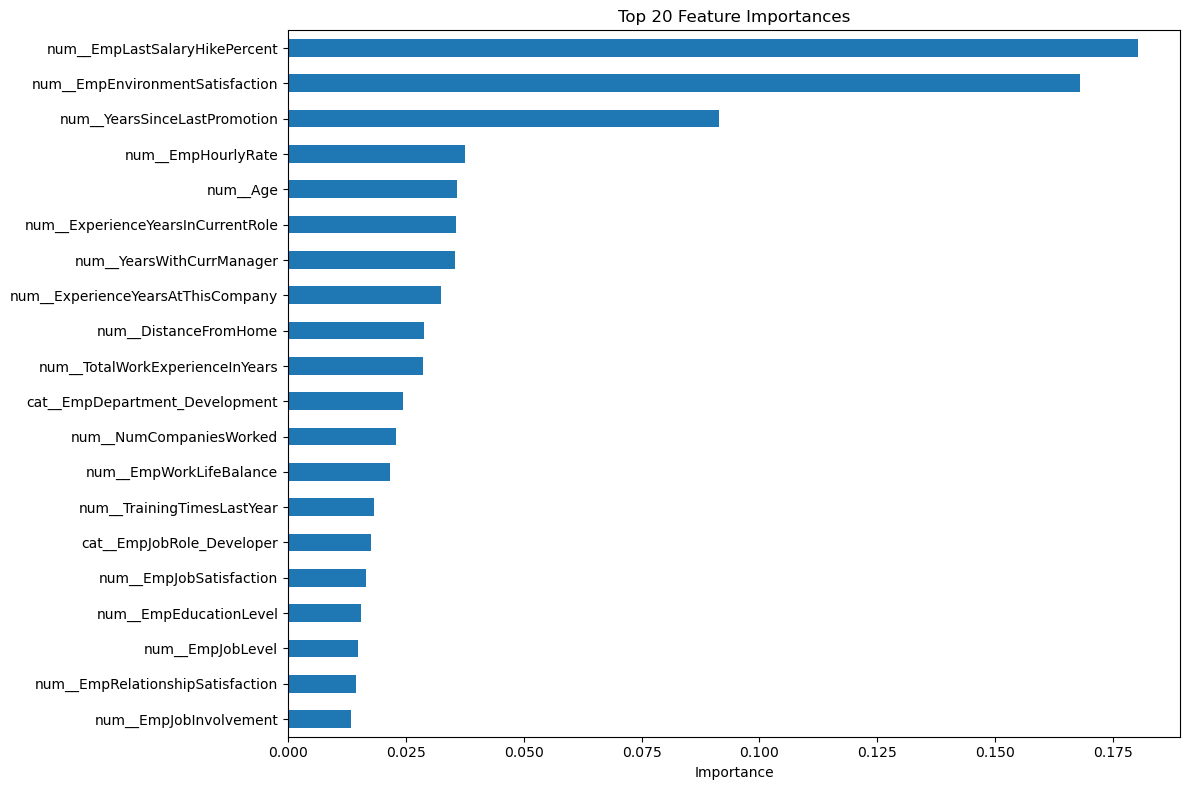

In [91]:
plt.figure(figsize=(12,8))

feature_importance.head(20).sort_values().plot(
    kind='barh'
)

plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

In [92]:
top_3_features = feature_importance.head(3)

top_3_features

num__EmpLastSalaryHikePercent      0.180184
num__EmpEnvironmentSatisfaction    0.167979
num__YearsSinceLastPromotion       0.091451
dtype: float64

In [93]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model_fitted.feature_importances_
})

importance_df.head()

,Feature,Importance
0,num__Age,0.035920
1,num__DistanceFromHome,0.028864
2,num__EmpEducationLevel,0.015447
3,num__EmpEnvironmentSatisfaction,0.167979
4,num__EmpHourlyRate,0.037529


In [94]:
importance_df['OriginalFeature'] = (
    importance_df['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

In [95]:
original_importance = (
    importance_df
    .groupby('OriginalFeature')['Importance']
    .sum()
    .sort_values(ascending=False)
)

original_importance

OriginalFeature
EmpLastSalaryHikePercent               0.180184
EmpEnvironmentSatisfaction             0.167979
YearsSinceLastPromotion                0.091451
EmpHourlyRate                          0.037529
Age                                    0.035920
                                         ...   
EmpJobRole_Senior Manager R&D          0.000794
EducationBackground_Human Resources    0.000689
EmpJobRole_Research Director           0.000428
EmpJobRole_Technical Architect         0.000039
EmpJobRole_Delivery Manager            0.000019
Name: Importance, Length: 61, dtype: float64

In [96]:
top_3_original = original_importance.head(3)

top_3_original

OriginalFeature
EmpLastSalaryHikePercent      0.180184
EmpEnvironmentSatisfaction    0.167979
YearsSinceLastPromotion       0.091451
Name: Importance, dtype: float64

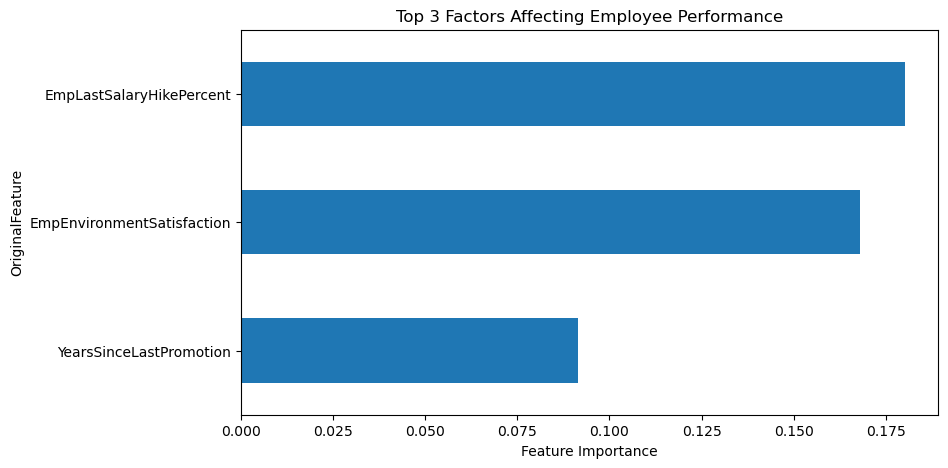

In [97]:
plt.figure(figsize=(9,5))

top_3_original.sort_values().plot(
    kind='barh'
)

plt.title('Top 3 Factors Affecting Employee Performance')
plt.xlabel('Feature Importance')

plt.show()

In [98]:
roc_auc_score(
    y_test,
    rf_grid.predict_proba(X_test),
    multi_class='ovr',
    average='weighted'
)

0.9374259364571821

In [99]:
if hasattr(rf_grid, "predict_proba"):
    
    best_probabilities = rf_grid.predict_proba(X_test)
    
    auc_score = roc_auc_score(
        y_test,
        best_probabilities,
        multi_class='ovr',
        average='weighted'
    )
    
    print("Weighted ROC-AUC:", auc_score)

Weighted ROC-AUC: 0.9374259364571821


In [100]:
from sklearn.preprocessing import label_binarize

classes = sorted(y.unique())

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

y_probability = rf_grid.predict_proba(X_test)

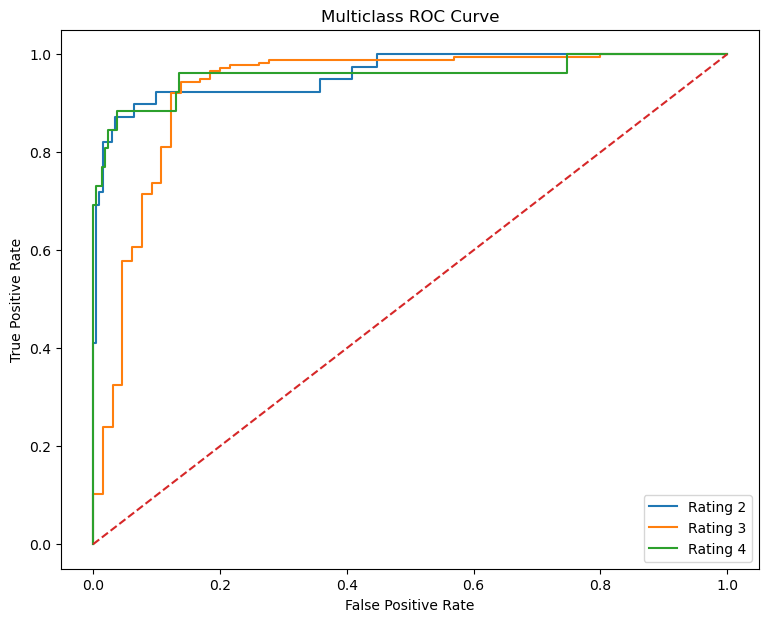

In [101]:
plt.figure(figsize=(9,7))

for i, class_value in enumerate(classes):
    
    fpr, tpr, _ = roc_curve(
        y_test_binary[:, i],
        y_probability[:, i]
    )
    
    plt.plot(
        fpr,
        tpr,
        label=f'Rating {class_value}'
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Multiclass ROC Curve')

plt.legend()

plt.show()

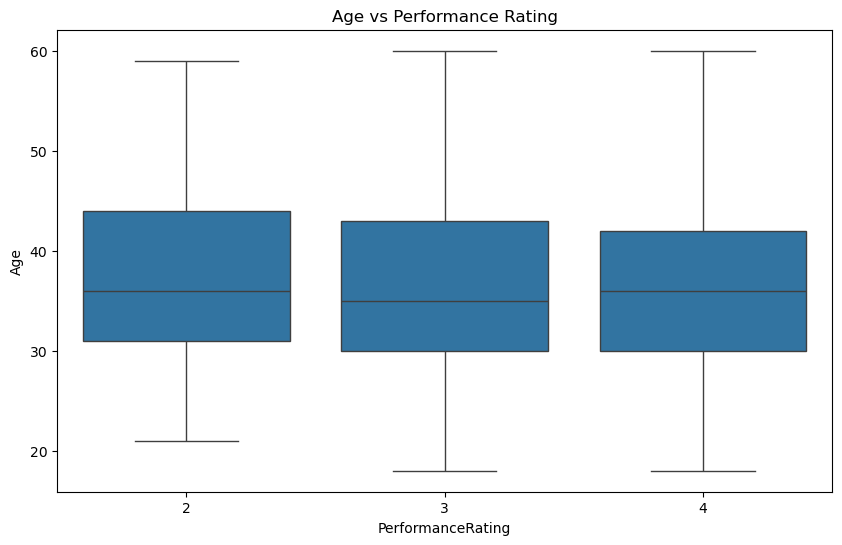

In [102]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='PerformanceRating',
    y='Age'
)

plt.title('Age vs Performance Rating')

plt.show()

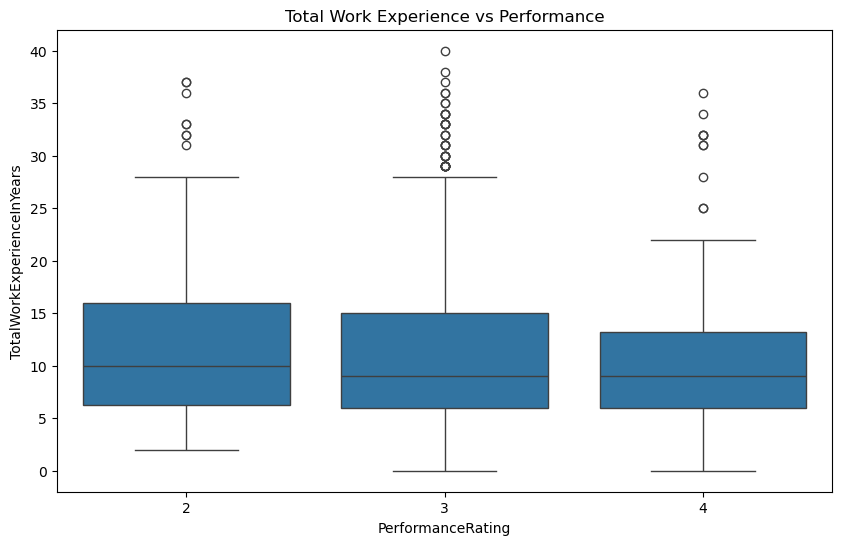

In [103]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='PerformanceRating',
    y='TotalWorkExperienceInYears'
)

plt.title(
    'Total Work Experience vs Performance'
)

plt.show()

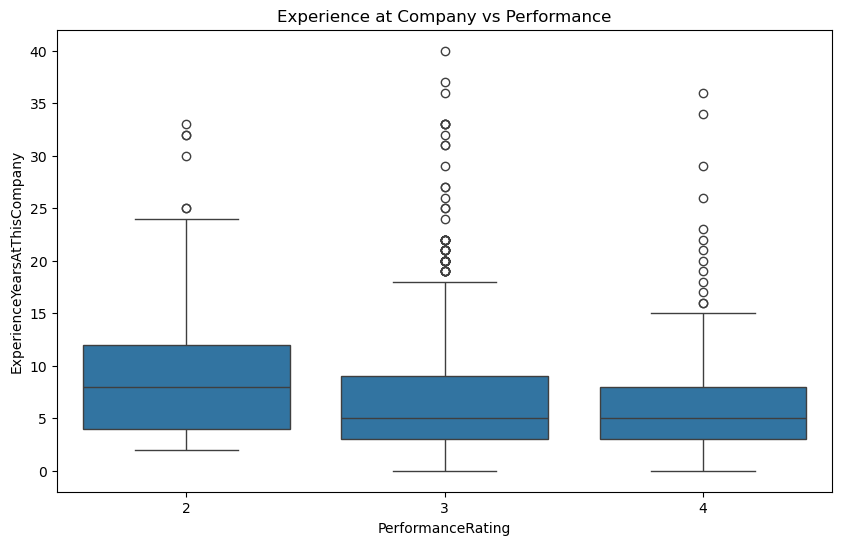

In [104]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='PerformanceRating',
    y='ExperienceYearsAtThisCompany'
)

plt.title(
    'Experience at Company vs Performance'
)

plt.show()

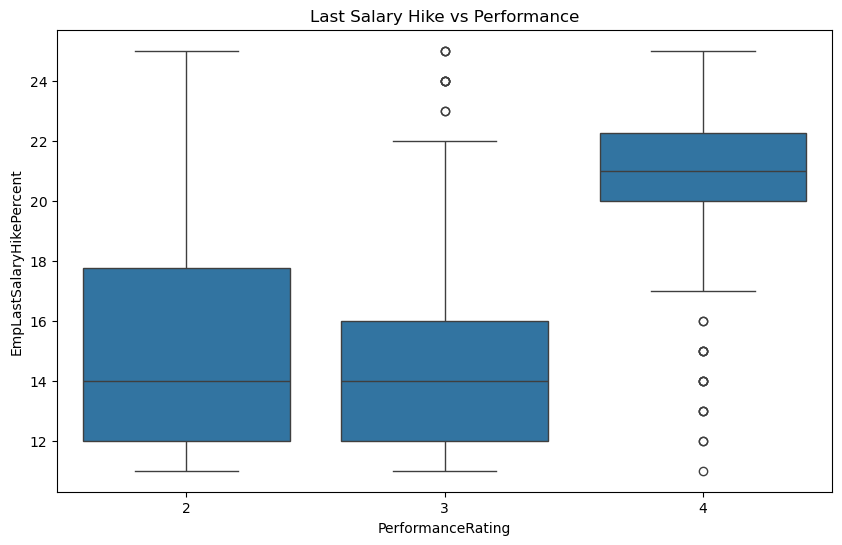

In [105]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='PerformanceRating',
    y='EmpLastSalaryHikePercent'
)

plt.title(
    'Last Salary Hike vs Performance'
)

plt.show()

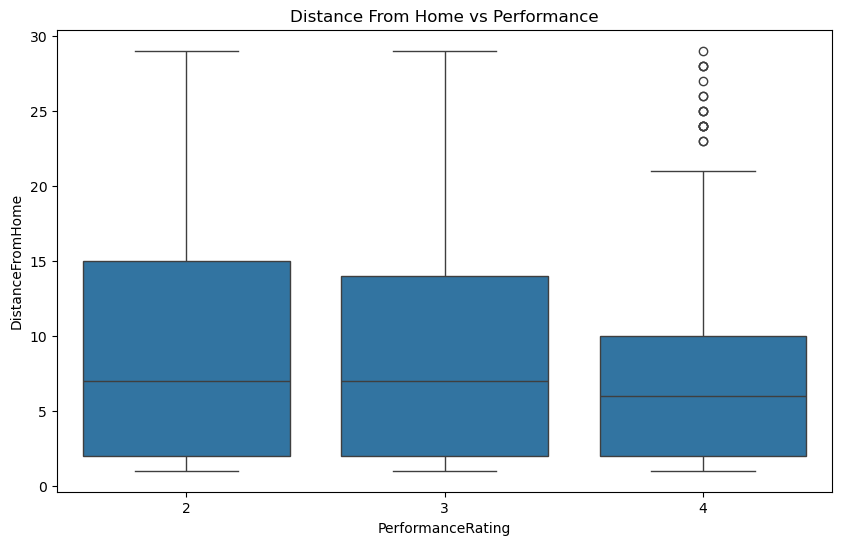

In [106]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='PerformanceRating',
    y='DistanceFromHome'
)

plt.title(
    'Distance From Home vs Performance'
)

plt.show()

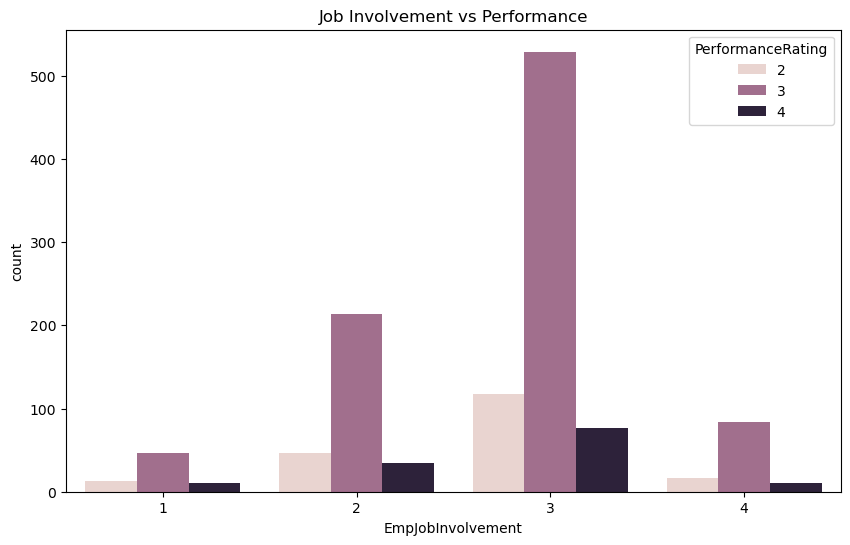

In [107]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='EmpJobInvolvement',
    hue='PerformanceRating'
)

plt.title(
    'Job Involvement vs Performance'
)

plt.show()

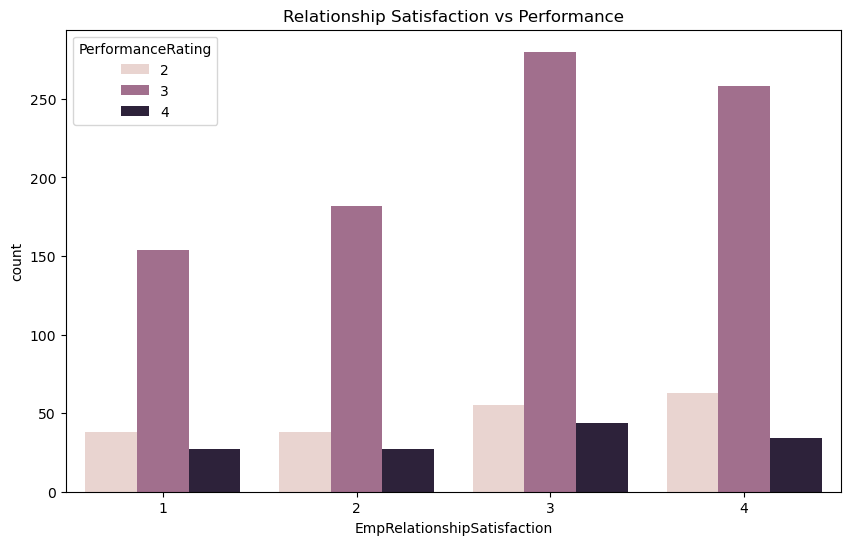

In [108]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='EmpRelationshipSatisfaction',
    hue='PerformanceRating'
)

plt.title(
    'Relationship Satisfaction vs Performance'
)

plt.show()

In [109]:
travel_performance = pd.crosstab(
    df['BusinessTravelFrequency'],
    df['PerformanceRating'],
    normalize='index'
) * 100

travel_performance

PerformanceRating,2,3,4
BusinessTravelFrequency,,,
Non-Travel,15.909091,70.454545,13.636364
Travel_Frequently,16.666667,69.369369,13.963964
Travel_Rarely,16.075650,74.113475,9.810875


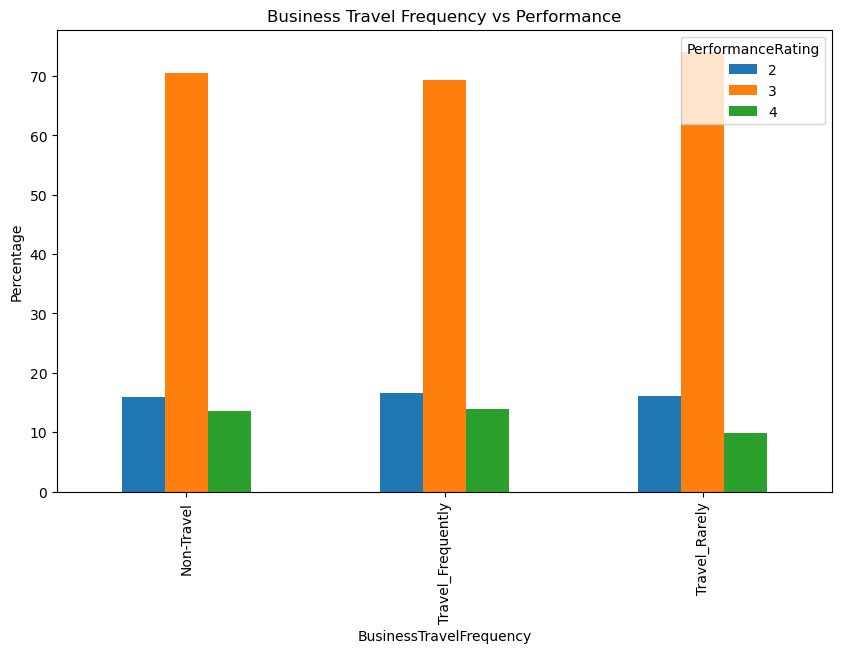

In [110]:
travel_performance.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Business Travel Frequency vs Performance'
)

plt.ylabel('Percentage')

plt.show()

In [111]:
attrition_performance = pd.crosstab(
    df['Attrition'],
    df['PerformanceRating'],
    normalize='index'
) * 100

attrition_performance

PerformanceRating,2,3,4
Attrition,,,
No,15.459883,73.385519,11.154599
Yes,20.224719,69.662921,10.112360


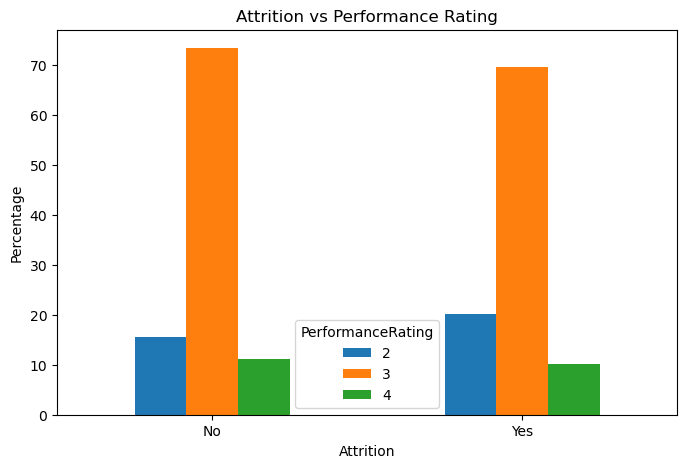

In [112]:
attrition_performance.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Attrition vs Performance Rating'
)

plt.ylabel('Percentage')

plt.xticks(rotation=0)

plt.show()

In [113]:
final_model = rf_grid

In [114]:
all_predictions = final_model.predict(X)

In [115]:
employee_predictions = df.copy()

employee_predictions[
    'PredictedPerformance'
] = all_predictions

In [116]:
low_performers = employee_predictions[
    employee_predictions['PredictedPerformance'] == 2
]

low_performers.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,PredictedPerformance
92,E1001171,38,Male,Marketing,Married,Sales,Sales Representative,Travel_Rarely,9,3,...,3,3,3,2,2,1,2,No,3,2
132,E1001248,37,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,1,4,...,17,2,1,14,1,11,7,Yes,2,2
162,E1001293,30,Female,Life Sciences,Married,Research & Development,Research Director,Travel_Rarely,8,2,...,9,4,2,8,7,1,7,No,2,2
164,E1001297,22,Male,Life Sciences,Married,Research & Development,Laboratory Technician,Travel_Rarely,8,1,...,4,3,2,4,3,1,1,No,2,2
165,E1001300,48,Male,Life Sciences,Single,Research & Development,Healthcare Representative,Travel_Rarely,6,3,...,19,0,3,2,2,2,2,No,2,2


In [117]:
low_performers.shape

(183, 29)

In [118]:
employee_predictions[
    'PredictedPerformance'
].value_counts()

PredictedPerformance
3    906
2    183
4    111
Name: count, dtype: int64

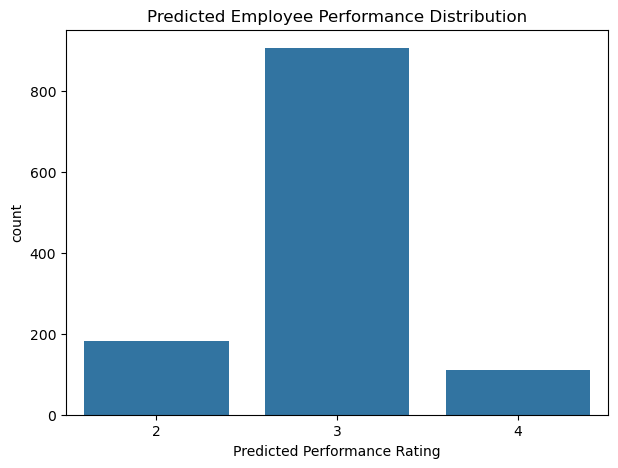

In [119]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=employee_predictions,
    x='PredictedPerformance'
)

plt.title(
    'Predicted Employee Performance Distribution'
)

plt.xlabel('Predicted Performance Rating')

plt.show()

In [120]:
employee_predictions.to_csv(
    'INX_Employee_Performance_Predictions.csv',
    index=False
)

In [121]:
import joblib

joblib.dump(
    final_model,
    'INX_Employee_Performance_Model.pkl'
)

['INX_Employee_Performance_Model.pkl']

In [122]:
loaded_model = joblib.load(
    'INX_Employee_Performance_Model.pkl'
)

In [123]:
new_employee = pd.DataFrame({
    'Age': [30],
    'Gender': ['Male'],
    'EducationBackground': ['Life Sciences'],
    'MaritalStatus': ['Single'],
    'EmpDepartment': ['Development'],
    'EmpJobRole': ['Developer'],
    'BusinessTravelFrequency': ['Rarely'],
    'DistanceFromHome': [5],
    'EmpEducationLevel': [3],
    'EmpEnvironmentSatisfaction': [3],
    'EmpHourlyRate': [60],
    'EmpJobInvolvement': [3],
    'EmpJobLevel': [2],
    'EmpJobSatisfaction': [3],
    'NumCompaniesWorked': [2],
    'OverTime': ['No'],
    'EmpLastSalaryHikePercent': [15],
    'EmpRelationshipSatisfaction': [3],
    'TotalWorkExperienceInYears': [5],
    'TrainingTimesLastYear': [3],
    'EmpWorkLifeBalance': [3],
    'ExperienceYearsAtThisCompany': [3],
    'ExperienceYearsInCurrentRole': [2],
    'YearsSinceLastPromotion': [1],
    'YearsWithCurrManager': [2],
    'Attrition': ['No']
})

In [124]:
prediction = final_model.predict(
    new_employee
)

print(
    "Predicted Performance Rating:",
    prediction[0]
)

Predicted Performance Rating: 3


In [125]:
probability = final_model.predict_proba(
    new_employee
)

print(probability)

[[0.02583333 0.93766667 0.0365    ]]


In [126]:
for rating, probability_value in zip(
    final_model.classes_,
    probability[0]
):
    
    print(
        f"Rating {rating}: "
        f"{probability_value:.2%}"
    )

Rating 2: 2.58%
Rating 3: 93.77%
Rating 4: 3.65%


In [127]:
final_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

final_precision = precision_score(
    y_test,
    tuned_rf_pred,
    average='weighted'
)

final_recall = recall_score(
    y_test,
    tuned_rf_pred,
    average='weighted'
)

final_f1 = f1_score(
    y_test,
    tuned_rf_pred,
    average='weighted'
)

final_auc = roc_auc_score(
    y_test,
    rf_grid.predict_proba(X_test),
    multi_class='ovr',
    average='weighted'
)

final_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ]
})

final_results


,Metric,Score
0,Accuracy,0.895833
1,Precision,0.902077
2,Recall,0.895833
3,F1 Score,0.888345
4,ROC-AUC,0.937426


In [128]:
top_10_factors = (
    original_importance
    .head(10)
    .reset_index()
)

top_10_factors.columns = [
    'Factor',
    'Importance'
]

top_10_factors

,Factor,Importance
0,EmpLastSalaryHikePercent,0.180184
1,EmpEnvironmentSatisfaction,0.167979
2,YearsSinceLastPromotion,0.091451
3,EmpHourlyRate,0.037529
4,Age,0.035920
5,ExperienceYearsInCurrentRole,0.035571
6,YearsWithCurrManager,0.035408
7,ExperienceYearsAtThisCompany,0.032542
8,DistanceFromHome,0.028864
9,TotalWorkExperienceInYears,0.028669


In [129]:
department_summary = df.groupby(
    'EmpDepartment'
).agg(
    Average_Performance=(
        'PerformanceRating',
        'mean'
    ),
    Employee_Count=(
        'PerformanceRating',
        'count'
    )
).sort_values(
    'Average_Performance',
    ascending=False
)

department_summary

,Average_Performance,Employee_Count
EmpDepartment,,
Development,3.085873,361
Data Science,3.050000,20
Human Resources,2.925926,54
Research & Development,2.921283,343
Sales,2.860590,373
Finance,2.775510,49


In [130]:
low_performance_percentage = (
    df.assign(
        LowPerformance=
        df['PerformanceRating'] == 2
    )
    .groupby('EmpDepartment')['LowPerformance']
    .mean()
    * 100
)

low_performance_percentage.sort_values(
    ascending=False
)

EmpDepartment
Finance                   30.612245
Sales                     23.324397
Research & Development    19.825073
Human Resources           18.518519
Data Science               5.000000
Development                3.601108
Name: LowPerformance, dtype: float64

In [131]:
print("========== INX FUTURE INC PROJECT SUMMARY ==========")

print("\nDataset Shape:")
print(df.shape)

print("\nTarget Variable:")
print("PerformanceRating")

print("\nDepartments:")
print(df['EmpDepartment'].nunique())

print("\nBest Performing Department:")
print(department_avg.idxmax())

print(
    "Average Performance:",
    round(department_avg.max(), 2)
)

print("\nLowest Performing Department:")
print(department_avg.idxmin())

print(
    "Average Performance:",
    round(department_avg.min(), 2)
)

print("\nTop 3 Factors:")
for factor in top_3_original.index:
    print("-", factor)

print("\nBest Model:")
print(best_model_name)

print("\nTuned Random Forest Metrics:")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))
print("ROC-AUC  :", round(final_auc, 4))

========== INX FUTURE INC PROJECT SUMMARY ==========

Dataset Shape:
(1200, 28)

Target Variable:
PerformanceRating

Departments:
6

Best Performing Department:
Development
Average Performance: 3.09

Lowest Performing Department:
Finance
Average Performance: 2.78

Top 3 Factors:
- EmpLastSalaryHikePercent
- EmpEnvironmentSatisfaction
- YearsSinceLastPromotion

Best Model:
Decision Tree

Tuned Random Forest Metrics:
Accuracy : 0.8958
Precision: 0.9021
Recall   : 0.8958
F1 Score : 0.8883
ROC-AUC  : 0.9374


In [132]:
print("""
RECOMMENDATIONS

1. Focus on the departments having the highest percentage of
   low-performance employees.

2. Improve the employee-related factors identified as the top
   three important predictors by the machine-learning model.

3. Provide targeted training and skill-development programs.

4. Improve employee engagement and job satisfaction.

5. Regularly monitor employee performance using the trained
   prediction model.

6. Use the model as a decision-support tool during recruitment
   rather than as the sole basis for hiring decisions.

7. Employees predicted to have lower performance should be
   supported with training, mentoring and appropriate feedback
   rather than immediately penalized.

8. Repeat the analysis periodically because employee behaviour
   and business conditions can change over time.
""")


RECOMMENDATIONS

1. Focus on the departments having the highest percentage of
   low-performance employees.

2. Improve the employee-related factors identified as the top
   three important predictors by the machine-learning model.

3. Provide targeted training and skill-development programs.

4. Improve employee engagement and job satisfaction.

5. Regularly monitor employee performance using the trained
   prediction model.

6. Use the model as a decision-support tool during recruitment
   rather than as the sole basis for hiring decisions.

7. Employees predicted to have lower performance should be
   supported with training, mentoring and appropriate feedback
   rather than immediately penalized.

8. Repeat the analysis periodically because employee behaviour
   and business conditions can change over time.



<b>Final Concblusion</b>

The INX Future Inc Employee Performance project analyzes employee-related factors and develops machine-learning models to predict employee performance ratings. The analysis includes department-wise performance, employee satisfaction, work experience, training, work-life balance, overtime and other relevant factors.

Several classification algorithms were developed and compared, including Logistic Regression, Decision Tree, Random Forest, KNN, SVM, Naive Bayes and Extra Trees. The models were evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC and cross-validation.

Feature-importance analysis was used to identify the three most influential factors associated with employee performance. These factors can help management understand areas that require attention and design targeted employee-development initiatives.

The trained model can also be used as a decision-support system for predicting employee performance. However, employee performance predictions should not be used as the sole basis for hiring or penalizing employees. The predictions should be combined with interviews, experience, skills, performance reviews and human judgment.

The project provides INX Future Inc with a data-driven approach to identifying performance-related patterns, improving employee development programs, supporting recruitment decisions and ultimately improving overall organizational performance and employee satisfaction.


In [134]:
top_3_original

OriginalFeature
EmpLastSalaryHikePercent      0.180184
EmpEnvironmentSatisfaction    0.167979
YearsSinceLastPromotion       0.091451
Name: Importance, dtype: float64